In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)   

pd.set_option("display.max_rows", None) 
pd.set_option("display.max_columns", None)    


print("Libraries loaded ")

Libraries loaded 


###  loda  the  data sets  

In [17]:
df = pd.read_csv("../../data/raw/telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
###  basic shape and structer    
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()  

Rows: 7043, Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

### find  the  missing  values    

In [19]:
df.isnull().sum().sort_values(ascending=False)   

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [20]:
###  comment  :   no any   missing  values    

###  fix  the  data  types   

In [21]:
### convert   the  TotalCharges  into  the numaric  values    
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

#detect   the   missing  values  after  convert  
print(f"Missing values after conversion: {df['TotalCharges'].isnull().sum()}")
df[df["TotalCharges"].isnull()]

Missing values after conversion: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


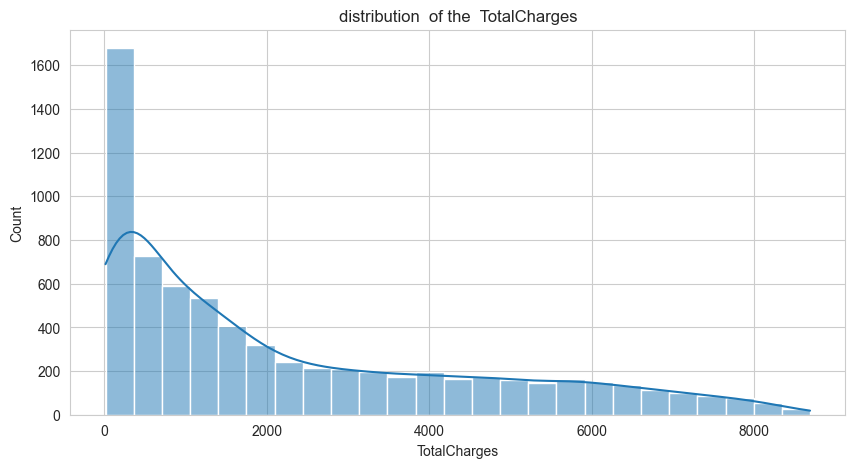

In [22]:
###  fill   the  missing  values   
sns.histplot(df["TotalCharges"]  ,  kde  =   True)   
plt.title("distribution  of the  TotalCharges")   
plt.show()   

In [23]:
###  remove  the  custromer  Id   

df.drop(columns=["customerID"], inplace=True)
###  fill  with  the  medain   values of  TotalCharges  
df["TotalCharges"]  =   df["TotalCharges"].fillna(df["TotalCharges"].median())
print("fil   the missing  values")   

fil   the missing  values


###  traget   variable  distributions    

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25576\226008377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["#2ecc71", "#e74c3c"])


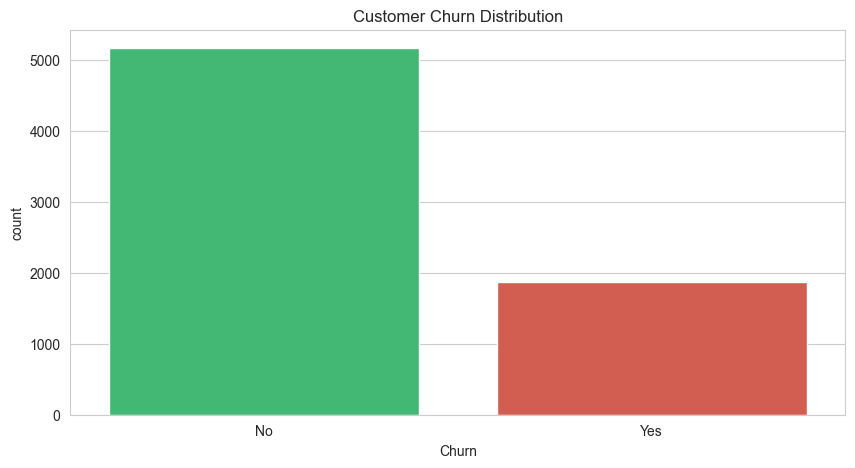

In [24]:
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

sns.countplot(data=df, x="Churn", palette=["#2ecc71", "#e74c3c"])
plt.title("Customer Churn Distribution")
plt.show()

In [26]:
###  take  the  numarca    columns    
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]    
num_cols   

['tenure', 'MonthlyCharges', 'TotalCharges']

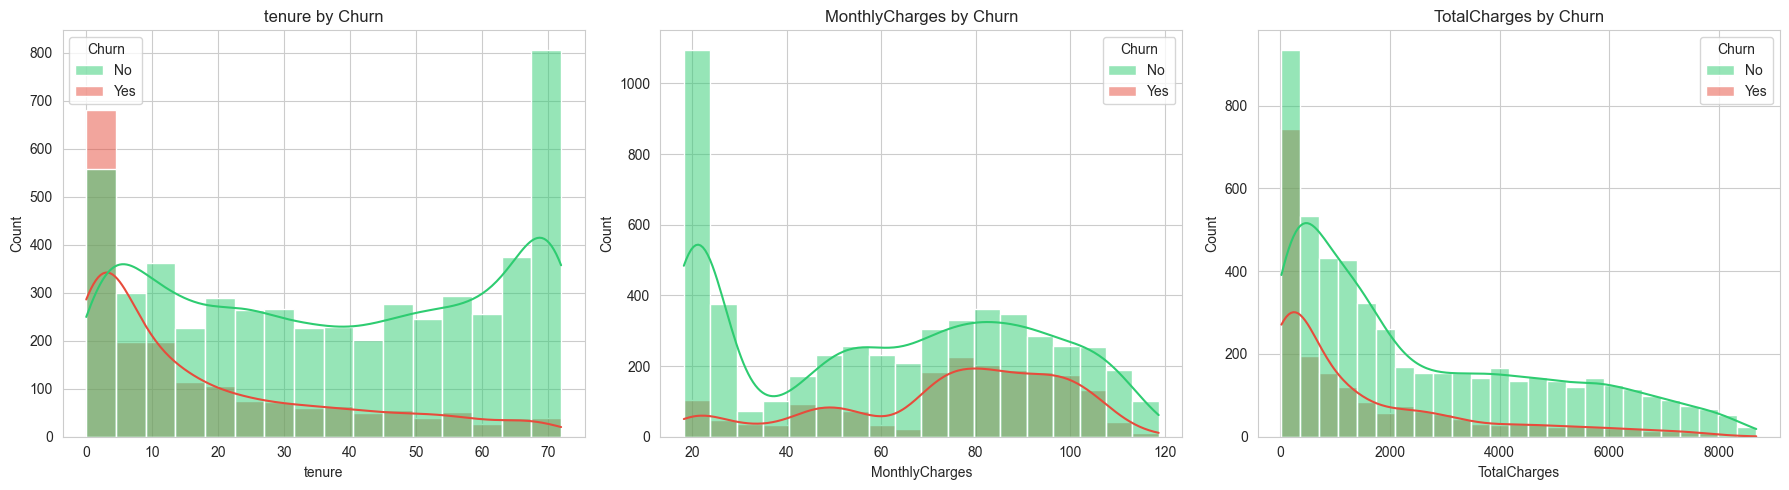

In [27]:
##  numarica  featuer  distributions    

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=axes[i], palette=["#2ecc71", "#e74c3c"])
    axes[i].set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

### Churn rate by contract type    

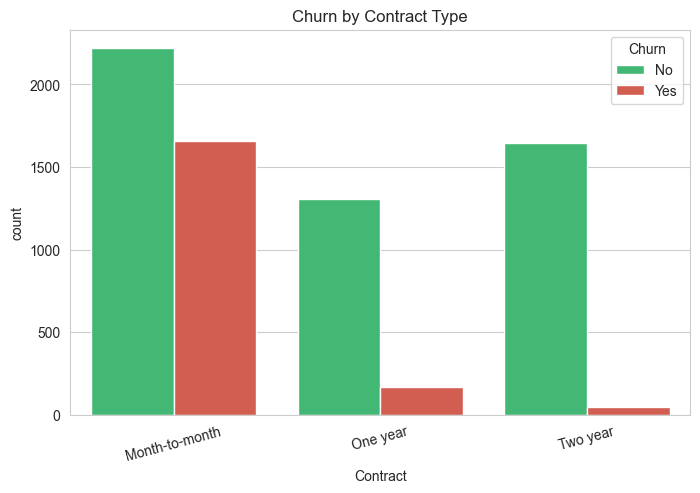

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette=["#2ecc71", "#e74c3c"])
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

### Churn rate by internet service and payment method

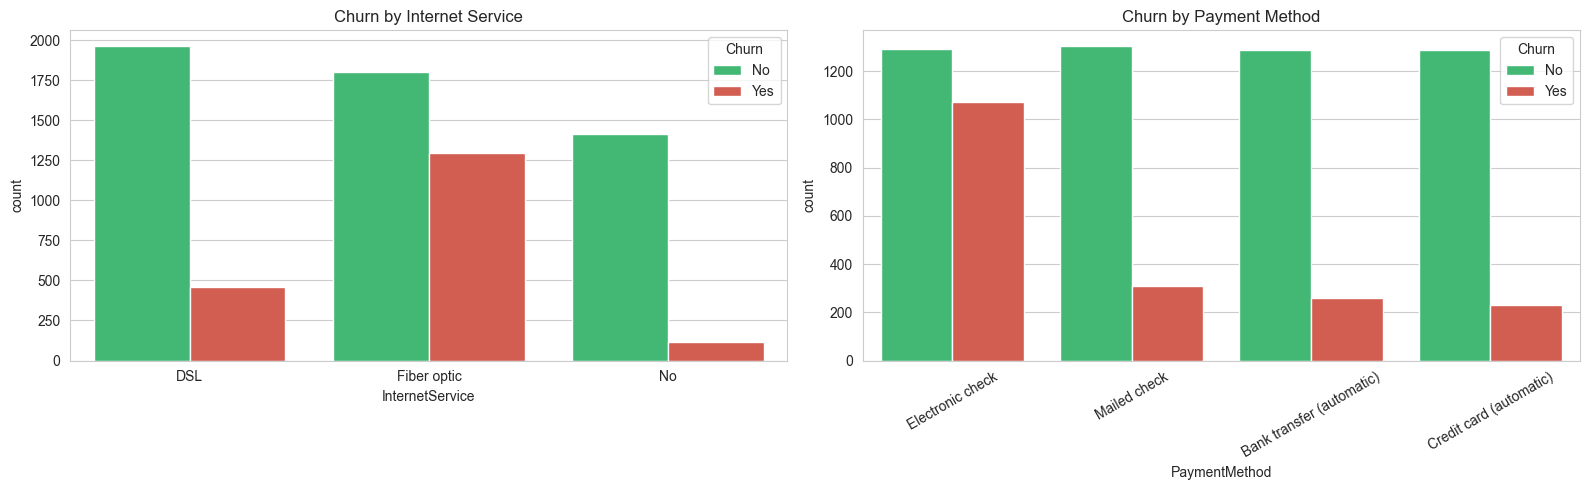

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn by Internet Service")

sns.countplot(data=df, x="PaymentMethod", hue="Churn", ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Churn by Payment Method")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [32]:
###  take  the  object   data   
obj_cols  =   [cols for cols   in    df.columns   if  df[cols].dtypes  ==   "object"]
obj_cols  

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [34]:
### comment  :  have to  convert   the  object  data  into   the  numarical  values   

###  Correlation heatmap    

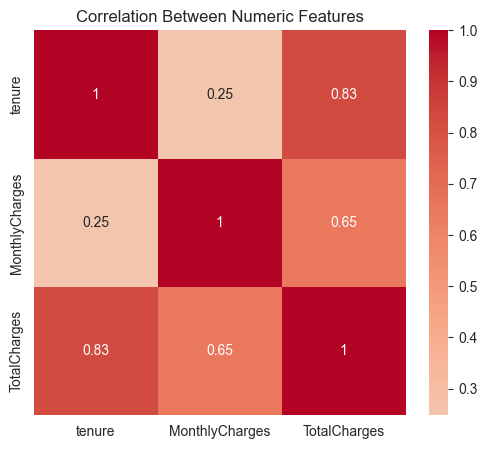

In [30]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Features")
plt.show()

### summary  of  the  EDA    


## Key EDA Findings
- Overall churn rate: ~26.5%
- Month-to-month contracts churn far more than one/two-year contracts
- Customers with Fiber optic internet churn more than DSL
- Electronic check payment method has notably higher churn
- Lower tenure customers are much more likely to churn